In [57]:
from utils import load_masks

import pandas as pd

In [58]:
df = load_masks()
df['has_ship'] = df['EncodedPixels'].apply(lambda x: 0 if pd.isna(x) or str(x).strip() == '' else 1)
df = df.drop(columns='EncodedPixels')

In [59]:
df.head()

,ImageId,has_ship
0,00003e153.jpg,0
1,0001124c7.jpg,0
2,000155de5.jpg,1
3,000194a2d.jpg,1
4,000194a2d.jpg,1


In [60]:
import cv2
import numpy as np

from typing import Tuple
from utils import get_image

In [61]:
def features(img_id: str) -> Tuple[float, float]:
    """
    Extract simple image features: edge ratio and grayscale variance.

    :param img_id: Image filename (with or without extension).
    :returns: Tuple containing (edge pixel ratio, grayscale variance) as floats.
    """
    img_id = img_id.split(".")[0]
    img = get_image(img_id)
    gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
    edges = cv2.Canny(gray, 100, 200)
    ratio = np.sum(edges > 0) / edges.size
    
    gray = gray /255.0
    variance = np.var(gray)
    return (ratio, variance)

In [62]:
from tqdm import tqdm
from sklearn.model_selection import train_test_split

tqdm.pandas() 

In [63]:
df_sample = df.sample(10000, random_state=42)

df_sample[['ratio', 'variance']] = pd.DataFrame(
    df_sample['ImageId'].progress_apply(lambda x: features(x)).tolist(),
    index=df_sample.index
)

X = df_sample[["ratio", "variance"]]
y = df_sample["has_ship"]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

100%|██████████| 10000/10000 [01:06<00:00, 149.33it/s]


In [64]:
import os
import joblib
import numpy as np

from typing import Optional
from sklearn.ensemble import RandomForestClassifier

In [65]:
MODEL_PATH = "./checkpoints/empty_filter_forest.pkl"

def get_model(
    X_train: Optional[np.ndarray] = None,
    y_train: Optional[np.ndarray] = None
) -> RandomForestClassifier:
    if os.path.exists(MODEL_PATH):
        print(f"Loading existing model from {MODEL_PATH}")
        return joblib.load(MODEL_PATH)

    model = RandomForestClassifier(
        class_weight="balanced",
        n_estimators=250,
        random_state=42
    )

    model.fit(X_train, y_train)
    os.makedirs(os.path.dirname(MODEL_PATH), exist_ok=True)

    joblib.dump(model, MODEL_PATH)
    return model

In [66]:
model = get_model(X_train, y_train)

Loading existing model from ./checkpoints/empty_filter_forest.pkl


In [67]:
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

Accuracy: 0.739

Classification report:
               precision    recall  f1-score   support

           0       0.79      0.81      0.80      1306
           1       0.63      0.60      0.61       694

    accuracy                           0.74      2000
   macro avg       0.71      0.71      0.71      2000
weighted avg       0.74      0.74      0.74      2000



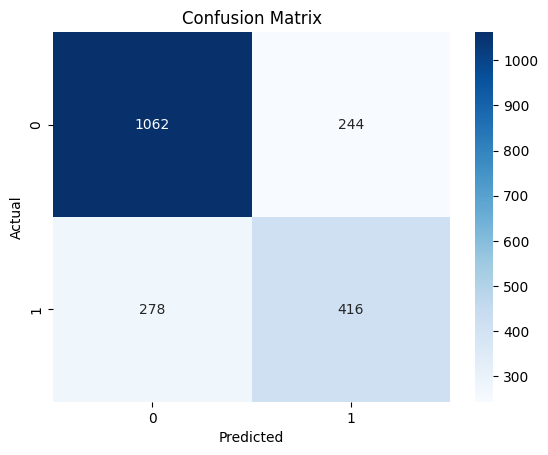

In [68]:
y_pred = model.predict(X_test)

cm = confusion_matrix(y_test, y_pred)
acc = accuracy_score(y_test, y_pred)

print("Accuracy:", acc)
print("\nClassification report:\n", classification_report(y_test, y_pred))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [69]:
def is_empty(img_path: str, prob_thresh: float = 0.7) -> bool:
    """
    Determine whether an image likely contains no ships based on edge and variance features.

    :param img_path: Path to the image file.
    :param prob_thresh: Probability threshold below which the image is considered empty.
    :returns: True if the image likely contains no ships, False otherwise.
    """
    img = get_image(img_path)
    gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
    edges = cv2.Canny(gray, 100, 200)
    ratio = np.sum(edges > 0) / edges.size
    variance = np.var(gray / 255.0)
    features = np.array([[ratio, variance]])
    probs = model.predict_proba(features)[0]
    prob_ship = probs[1]
    return prob_ship < prob_thresh

In [70]:
is_empty("0a0c7f8d1")

/Users/lorinctoldi/University/Subjects/Deep-Learning/homework/venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


np.True_

In [71]:
is_empty("0a8d5d261")

/Users/lorinctoldi/University/Subjects/Deep-Learning/homework/venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


np.False_